In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

In [2]:
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
merged_df = merged_df[['disease', 'setting', 'method', 'category',
                        'bio_sim_300', 'bio_sim_150',
                        'top_recall_150', 'succ_150',
                        'top_recall_300', 'succ_300',
                        'bedroc_150', 'bedroc_300', 'auroc']]

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

## no category

In [ ]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 + (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    if pooled_std == 0:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled_std

def mean_diff(a, b):
    """Calculate mean differences between two groups."""

    return (np.mean(a) - np.mean(b))

def run_ttest(vals_a, vals_b):
    if len(vals_a) < 2 or len(vals_b) < 2:
        return np.nan, np.nan
    _, p_value = stats.ttest_ind(vals_a, vals_b, equal_var=False)
    effect_size = cohens_d(vals_a, vals_b)
    return p_value, effect_size

import numpy as np

def run_permutation_test(vals_a, vals_b, n_permutations=10000, random_state=None):
    vals_a = np.asarray(vals_a)
    vals_b = np.asarray(vals_b)

    if len(vals_a) < 2 or len(vals_b) < 2:
        return np.nan, np.nan

    observed_stat = np.mean(vals_a) - np.mean(vals_b)
    combined = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)

    rng = np.random.default_rng(random_state)

    perm_stats = np.empty(n_permutations)
    for i in range(n_permutations):
        permuted = rng.permutation(combined)
        perm_a = permuted[:n_a]
        perm_b = permuted[n_a:]
        perm_stats[i] = np.mean(perm_a) - np.mean(perm_b)

    p_value = (np.sum(np.abs(perm_stats) >= np.abs(observed_stat)) + 1) / (n_permutations + 1)
    # effect_size = cohens_d(vals_a, vals_b)
    effect_size = mean_diff(vals_a, vals_b)

    return p_value, effect_size

def feature_compare(merged_df):
    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']
    settings = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred', 'graphsage', 'gcn']

    map_name = {
        'df_gnn_occsvm_pred':   'SVM_features',
        '2019_nn_all_pred':     'DNN_features',
        '2019_rf_renamed_pred': 'RF_features',
        '2019_mf_add_pred':     'MF_features',
        'graphsage':            'GraphSAGE_features',
        'gcn':                  'GCN_features'
    }

    ppi_features = [f for f in selected_features if f.startswith('ppi_')]
    lit_features = [f for f in selected_features if f.startswith('literature_')]
    seq_features = [f for f in selected_features if f.startswith('seq_')]

    comparison_pairs = (
        [(p, l) for p in ppi_features for l in lit_features] +
        [(p, s) for p in ppi_features for s in seq_features] +
        [(l, s) for l in lit_features for s in seq_features]
    )

    filtered_df = merged_df[merged_df['setting'].isin(settings) & merged_df['method'].isin(selected_features)]

    results = []

    for metric in selected_metrics:
        for feat_a, feat_b in comparison_pairs:
            vals_a = filtered_df[filtered_df['method'] == feat_a][metric].dropna().values
            vals_b = filtered_df[filtered_df['method'] == feat_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)

            results.append({
                'setting':         'across_models',
                'metric':          metric,
                'compared_groups': f'{feat_a} vs {feat_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })

    # for setting in settings:
    #     setting_df = filtered_df[filtered_df['setting'] == setting]
    #     for metric in selected_metrics:
    #         for feat_a, feat_b in comparison_pairs:
    #             vals_a = setting_df[setting_df['method'] == feat_a][metric].dropna().values
    #             vals_b = setting_df[setting_df['method'] == feat_b][metric].dropna().values
    #             # p_value, effect_size = run_ttest(vals_a, vals_b)
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)
                
    #             results.append({
    #                 'setting':         map_name.get(setting, setting),
    #                 'metric':          metric,
    #                 'compared_groups': f'{feat_a} vs {feat_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    return pd.DataFrame(results)


def model_compare(merged_df):
    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

    # selected_pairs_template = [
    #     ('df_gnn_occsvm_pred',   None),
    #     ('graphsage',            None),
    #     ('gcn',                  None),
    #     ('2019_nn_all_pred',     None),
    #     ('2019_rf_renamed_pred', None),
    #     ('2019_mf_add_pred',     None),
    # ]
    model_names = ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    results = []

    method_mapping = {
        'df_gnn_occsvm_pred':   'SVM',
        'graphsage':            'GraphSAGE',
        'gcn':                  'GCN',
        '2019_nn_all_pred':     'DNN',
        '2019_rf_renamed_pred': 'RF',
        '2019_mf_add_pred':     'MF',
    }
    
    subresults = merged_df[merged_df['method'].isin(selected_features)]
    subresults['model'] = subresults['setting'].map(method_mapping)

    models = subresults['model'].unique()  # ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    for metric in selected_metrics:
        for model_a, model_b in combinations(models, 2):
            vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
            vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)

            results.append({
                'feature':         'across_features',
                'metric':          metric,
                'compared_groups': f'{model_a} vs {model_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })
    # for feature_i in selected_features:
    #     selected_pairs = [(s, feature_i) for s, _ in selected_pairs_template]
    #     method_mapping = dict(zip(selected_pairs, model_names))

    #     subresults = merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index()
    #     subresults['model'] = [method_mapping[(row['setting'], row['method'])]
    #                            for _, row in subresults.iterrows()]

    #     for metric in selected_metrics:
    #         for model_a, model_b in combinations(model_names, 2):
    #             vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
    #             vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
    #             # p_value, effect_size = run_ttest(vals_a, vals_b)
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)

                
    #             results.append({
    #                 'feature':         feature_i,
    #                 'metric':          metric,
    #                 'compared_groups': f'{model_a} vs {model_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    return pd.DataFrame(results)


# ── Main ──────────────────────────────────────────────────────────────────────

feature_results = feature_compare(merged_df)
model_results   = model_compare(merged_df)

/tmp/ipykernel_624892/3452222900.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['model'] = subresults['setting'].map(method_mapping)


In [63]:

feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features(across).csv',index=False)
model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models(across).csv',index=False)

In [62]:
feature_results

,setting,metric,compared_groups,p_value,effect_size
0,across_models,bio_sim_300,ppi_emb_df vs literature_emb,0.121388,-0.012956
1,across_models,bio_sim_300,ppi_emb_dw vs literature_emb,0.679132,-0.003541
2,across_models,bio_sim_300,ppi_emb_n2v vs literature_emb,0.524248,-0.005472
3,across_models,bio_sim_300,ppi_emb_df vs seq_emb_esm,0.063694,0.014500
4,across_models,bio_sim_300,ppi_emb_df vs seq_emb_port,0.106089,0.012704
...,...,...,...,...,...
72,across_models,auroc,ppi_emb_dw vs seq_emb_port,0.000100,0.095690
73,across_models,auroc,ppi_emb_n2v vs seq_emb_esm,0.000100,0.095136
74,across_models,auroc,ppi_emb_n2v vs seq_emb_port,0.000100,0.086929
75,across_models,auroc,literature_emb vs seq_emb_esm,0.000700,0.058346


In [ ]:
feature_results[(feature_results['effect_size']>=0.3)|(feature_results['effect_size']<=-0.3)]

In [ ]:

model_results[(model_results['effect_size']>=0.3)|(model_results['effect_size']<=-0.3)]

## categories

### features

In [7]:
def cohens_d(a, b):
    """Calculate Cohen's d effect size between two groups."""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 + (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    if pooled_std == 0:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled_std

def mean_diff(a, b):
    """Calculate mean differences between two groups."""

    return (np.mean(a) - np.mean(b))

def feature_compare(merged_df, c):
    c_df = merged_df[merged_df['category'] == c].copy()
    sample_size = int(c[-2])

    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']
    settings = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred', 'graphsage', 'gcn']

    map_name = {
        'df_gnn_occsvm_pred': 'SVM_features',
        '2019_nn_all_pred':   'DNN_features',
        '2019_rf_renamed_pred': 'RF_features',
        '2019_mf_add_pred':   'MF_features',
        'graphsage':          'GraphSAGE_features',
        'gcn':                'GCN_features'
    }

    ppi_features = [f for f in selected_features if f.startswith('ppi_')]
    lit_features = [f for f in selected_features if f.startswith('literature_')]
    seq_features = [f for f in selected_features if f.startswith('seq_')]

    # Each pair is (feature_a, feature_b), one from each group
    comparison_pairs = (
        [(p, l) for p in ppi_features for l in lit_features] +  # ppi vs literature
        [(p, s) for p in ppi_features for s in seq_features] +  # ppi vs seq
        [(l, s) for l in lit_features for s in seq_features]    # literature vs seq
    )

    results = []

    filtered_df = c_df[(c_df['method'].isin(selected_features))]

    for metric in selected_metrics:
        for feat_a, feat_b in comparison_pairs:
            vals_a = filtered_df[filtered_df['method'] == feat_a][metric].dropna().values
            vals_b = filtered_df[filtered_df['method'] == feat_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)

            results.append({
                'category':        c,
                'sample_size':     sample_size,
                'setting':         'across_models',
                'metric':          metric,
                'compared_groups': f'{feat_a} vs {feat_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })

    return pd.DataFrame(results, columns=['category', 'sample_size', 'setting', 'metric',
                                            'compared_groups', 'p_value', 'effect_size'])
    # for setting in settings:
    #     filtered_df = c_df[(c_df['setting'] == setting) & (c_df['method'].isin(selected_features))]

    #     if filtered_df.empty:
    #         continue

    #     for metric in selected_metrics:
    #         for feat_a, feat_b in comparison_pairs:
    #             vals_a = filtered_df[filtered_df['method'] == feat_a][metric].dropna().values
    #             vals_b = filtered_df[filtered_df['method'] == feat_b][metric].dropna().values
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)

    #             results.append({
    #                 'category':        c,
    #                 'sample_size':     sample_size,
    #                 'setting':         map_name.get(setting, setting),
    #                 'metric':          metric,
    #                 'compared_groups': f'{feat_a} vs {feat_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    # return pd.DataFrame(results, columns=['category', 'sample_size', 'setting', 'metric',
    #                                       'compared_groups', 'p_value', 'effect_size'])


# ── Main ──────────────────────────────────────────────────────────────────────
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
merged_df = merged_df[['disease', 'setting', 'method', 'category',
                        'bio_sim_300', 'bio_sim_150',
                        'top_recall_150', 'succ_150',
                        'top_recall_300', 'succ_300',
                        'bedroc_150', 'bedroc_300', 'auroc']]

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

all_results = pd.concat(
    [feature_compare(merged_df, c) for c in merged_df['category'].unique()],
    ignore_index=True
)

In [8]:
all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',index=False)

In [5]:
all_results = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_category.csv')

In [12]:
all_results

,category,sample_size,setting,metric,compared_groups,p_value,effect_size
0,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs literature_emb,0.007599,-0.037437
1,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_dw vs literature_emb,0.090291,-0.025350
2,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_n2v vs literature_emb,0.122688,-0.022925
3,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs seq_emb_esm,0.292471,-0.013293
4,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs seq_emb_port,0.431857,-0.009510
...,...,...,...,...,...,...,...
842,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_dw vs seq_emb_port,0.029697,0.161761
843,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_n2v vs seq_emb_esm,0.032397,0.171742
844,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_n2v vs seq_emb_port,0.026997,0.166850
845,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,literature_emb vs seq_emb_esm,0.049995,0.156806


In [9]:
target_metrics = ['top_recall_150', 'top_recall_300', 'bedroc_150', 'bedroc_300']

In [4]:
all_results['metric'].unique()

array(['bio_sim_300', 'bio_sim_150', 'top_recall_150', 'top_recall_300',
       'bedroc_150', 'bedroc_300', 'auroc'], dtype=object)

In [5]:
import matplotlib.pyplot as plt

(array([   7.,    0.,   53.,  139., 3189., 1276.,  330.,   32.,   17.,
          39.]),
 array([-0.66666667, -0.52222222, -0.37777778, -0.23333333, -0.08888889,
         0.05555556,  0.2       ,  0.34444444,  0.48888889,  0.63333333,
         0.77777778]),
 <BarContainer object of 10 artists>)

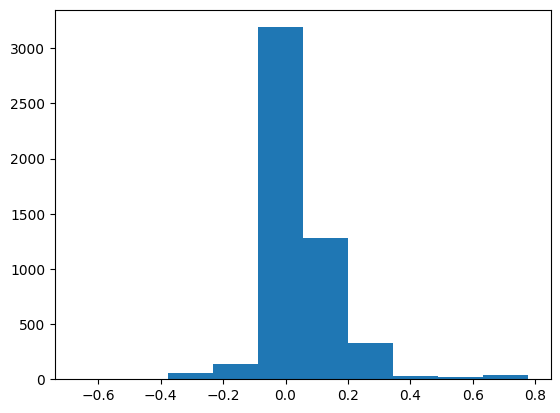

In [6]:
plt.hist(all_results['effect_size'])

### sub analysis for feature-model combination

In [ ]:
def summarize_conditions(high_effect_summary, c, target_metrics):
    target_set = set(target_metrics)
    
    def has_early(x):
        return len(set(x) & target_set) >= 2
    
    def has_bio(x):
        return any('bio' in m for m in x)
    
    def make_emb(df):
        df = df.copy()
        df['compared_groups_emb'] = (
            df['compared_groups']
            .str.split('vs')
            .apply(lambda x: '-'.join([item.strip()[:3] for item in x]))
        )
        return df['compared_groups_emb'].value_counts()
    
    # Base filter (category)
    base = high_effect_summary[high_effect_summary['category'] == c]
    
    # 1. high early discovery, no biosim
    cond1 = base[
        base['metric_lists'].apply(has_early) &
        base['metric_lists'].apply(lambda x: not has_bio(x))
    ]
    
    # 2. high early discovery, with biosim
    cond2 = base[
        base['metric_lists'].apply(has_early) &
        base['metric_lists'].apply(has_bio)
    ]
    
    # 3. no early discovery, but biosim
    cond3 = base[
        base['metric_lists'].apply(lambda x: not has_early(x)) &
        base['metric_lists'].apply(has_bio)
    ]
    
    return {
        'high_early_no_bio': make_emb(cond1),
        'high_early_with_bio': make_emb(cond2),
        'low_early_with_bio': make_emb(cond3),
    }

In [ ]:
positive_effect = dict()
high_effect = all_results[(all_results['effect_size']>=0.5)].copy()
high_effect_summary = high_effect[['category', 'setting', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'setting', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
for c in high_effect_summary['category'].unique():
    positive_effect[c] = summarize_conditions(high_effect_summary, c, target_metrics)

In [ ]:
rows = []

for disease, sub_dict in positive_effect.items():
    for category, series in sub_dict.items():
        if series is None or len(series) == 0:
            continue  # skip empty Series
        
        for method, count in series.items():
            rows.append({
                "category": disease,
                "condition": category,
                "method": method,
                "count": count
            })

positive_effect_df = pd.DataFrame(rows)

denominator_map = {
    "ppi-seq": 36,
    "ppi-lit": 18,
    "lit-seq": 12
}

positive_effect_df["normalized_count"] = (
    positive_effect_df["count"] /
    positive_effect_df["method"].map(denominator_map)
)

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'high_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'high_early_no_bio')].sort_values(by=['category', 'method'])

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'low_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect = dict()
high_effect = all_results[(all_results['effect_size']<=-0.5)].copy()
high_effect_summary = high_effect[['category', 'setting', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'setting', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
for c in high_effect_summary['category'].unique():
    negative_effect[c] = summarize_conditions(high_effect_summary, c, target_metrics)

In [ ]:
rows = []

for disease, sub_dict in negative_effect.items():
    for category, series in sub_dict.items():
        if series is None or len(series) == 0:
            continue  # skip empty Series
        
        for method, count in series.items():
            rows.append({
                "category": disease,
                "condition": category,
                "method": method,
                "count": count
            })

negative_effect_df = pd.DataFrame(rows)

denominator_map = {
    "ppi-seq": 36,
    "ppi-lit": 18,
    "lit-seq": 12
}

negative_effect_df["normalized_count"] = (
    negative_effect_df["count"] /
    negative_effect_df["method"].map(denominator_map)
)

negative_effect_df['method'] = (
    negative_effect_df['method']
    .str.split('-', expand=True)
    .apply(lambda x: x[1] + '-' + x[0], axis=1)
)

# negative_effect_df[negative_effect_df['normalized_count']>0.3]

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'high_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'high_early_no_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'low_early_with_bio')].sort_values(by=['category', 'method'])

### model compara

In [13]:
def model_compare(merged_df, c):
    c_df = merged_df[merged_df['category'] == c].copy()
    sample_size = int(c[-2])

    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

    results = []

    method_mapping = {
        'df_gnn_occsvm_pred':   'SVM',
        'graphsage':            'GraphSAGE',
        'gcn':                  'GCN',
        '2019_nn_all_pred':     'DNN',
        '2019_rf_renamed_pred': 'RF',
        '2019_mf_add_pred':     'MF',
    }
    
    subresults = c_df[c_df['method'].isin(selected_features)]
    subresults['model'] = subresults['setting'].map(method_mapping)

    models = subresults['model'].unique()  # ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    for metric in selected_metrics:
        for model_a, model_b in combinations(models, 2):
            vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
            vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)


            results.append({
                'category':        c,
                'sample_size':     sample_size,
                'feature':         'across_features',
                'metric':          metric,
                'compared_groups': f'{model_a} vs {model_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })

    # for feature_i in selected_features:
    #     selected_pairs = [
    #         ('df_gnn_occsvm_pred',    feature_i),
    #         ('graphsage',             feature_i),
    #         ('gcn',                   feature_i),
    #         ('2019_nn_all_pred',      feature_i),
    #         ('2019_rf_renamed_pred',  feature_i),
    #         ('2019_mf_add_pred',      feature_i),
    #     ]
    #     method_mapping = dict(zip(selected_pairs, ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']))

    #     subresults = c_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index()
    #     subresults['model'] = [method_mapping[(row['setting'], row['method'])]
    #                            for _, row in subresults.iterrows()]

    #     models = subresults['model'].unique()  # ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    #     for metric in selected_metrics:
    #         for model_a, model_b in combinations(models, 2):
    #             vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
    #             vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)


    #             results.append({
    #                 'category':        c,
    #                 'sample_size':     sample_size,
    #                 'feature':         feature_i,
    #                 'metric':          metric,
    #                 'compared_groups': f'{model_a} vs {model_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    return pd.DataFrame(results, columns=['category', 'sample_size', 'feature', 'metric',
                                          'compared_groups', 'p_value', 'effect_size'])


# ── Main ──────────────────────────────────────────────────────────────────────
from itertools import combinations

all_results2 = pd.concat(
    [model_compare(merged_df, c) for c in merged_df['category'].unique()],
    ignore_index=True
)

/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['model'] = subresults['setting'].map(method_mapping)
/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['model'] = subresults['setting'].map(method_mapping)
/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [14]:
all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',index=False)

In [15]:
all_results2

,category,sample_size,feature,metric,compared_groups,p_value,effect_size
0,Neoplasms(8),8,across_features,bio_sim_300,SVM vs DNN,0.633537,0.006834
1,Neoplasms(8),8,across_features,bio_sim_300,SVM vs RF,0.411459,0.011420
2,Neoplasms(8),8,across_features,bio_sim_300,SVM vs MF,0.000500,0.045655
3,Neoplasms(8),8,across_features,bio_sim_300,SVM vs GraphSAGE,0.744826,-0.004422
4,Neoplasms(8),8,across_features,bio_sim_300,SVM vs GCN,0.000400,0.050500
...,...,...,...,...,...,...,...
1150,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,RF vs GraphSAGE,0.709729,-0.024982
1151,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,RF vs GCN,0.397960,-0.068433
1152,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,MF vs GraphSAGE,0.848715,-0.009145
1153,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,MF vs GCN,0.215078,-0.052596


In [ ]:
# all_results2[(all_results2['effect_size']>=0.5)&(all_results2['category']=='Neoplasms(8)')]
high_effect = all_results2[(all_results2['effect_size']>=-0.5)].copy()
high_effect_summary = high_effect[['category', 'feature', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'feature', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
high_effect_summary[high_effect_summary['category']=='Neoplasms(8)']

## save all

In [11]:
selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

map_name = {
    'df_gnn_occsvm_pred': 'SVM',
    '2019_nn_all_pred':   'DNN',
    '2019_rf_renamed_pred': 'RF',
    '2019_mf_add_pred':   'MF',
    'graphsage':          'GraphSAGE',
    'gcn':                'GCN'
}

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'succ_150','succ_300',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

mean_df = merged_df[merged_df['method'].isin(selected_features)].copy()
mean_df['model'] = mean_df['setting'].map(map_name)


In [12]:
# --- method-level mean ---
method_df = (
    mean_df
    .groupby(['category', 'method'])[selected_metrics]
    .mean()
    .reset_index()
)

# --- model-level mean ---
model_df = (
    mean_df
    .groupby(['category', 'model'])[selected_metrics]
    .mean()
    .reset_index()
)

# final outputs
method_df = method_df[['category', 'method'] + selected_metrics]
model_df = model_df[['category', 'model'] + selected_metrics]

In [14]:
merged_df['method'].unique()

array(['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi',
       'ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb',
       'seq_emb_esm', 'seq_emb_port', 'mid_linear_fused', 'mid_geo_fused',
       'mid_linear_fused_ppi', 'mid_geo_fused_ppi', 'occ_svm',
       'uniport_ppi_2019', 'mid_fused', 'mid_fused_ppi'], dtype=object)

In [15]:
merged_df['setting'].unique()

array(['df_gnn_occsvm_pred', '2019_occ_deep_svd_pred/pred.pkl',
       '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred',
       'graphsage', 'gcn'], dtype=object)

In [16]:
selected_pairs = [('df_gnn_occsvm_pred', 'occ_svm'),
    ('df_gnn_occsvm_pred', 'ppi_emb_n2v'),
    ('2019_nn_all_pred', 'ppi_emb_n2v'),
    ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019')]
subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())

method_map = {
    ('df_gnn_occsvm_pred', 'occ_svm'): 'occ-svm',
    ('df_gnn_occsvm_pred', 'ppi_emb_n2v'): 'bagging-svm',
    ('2019_nn_all_pred', 'ppi_emb_n2v'): 'bagging-dnn',
    ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019'): 'occ-deepsvdd',
}

# (optional but recommended) normalize strings to avoid hidden whitespace issues
subresults['setting'] = subresults['setting'].astype(str).str.strip()
subresults['method']  = subresults['method'].astype(str).str.strip()

# build a MultiIndex key per row and map using the dict
keys = pd.MultiIndex.from_frame(subresults[['setting', 'method']])
new_method = keys.map(method_map)  # returns array with mapped values or NaN

# apply mapped names where available
subresults.loc[~pd.isna(new_method), 'method'] = new_method[~pd.isna(new_method)]

subresults = subresults.sort_values("category").reset_index(drop=True)



In [18]:

oc_df = (
    subresults
    .groupby(['category', 'method'])[selected_metrics]
    .mean()
    .reset_index()
)

In [20]:
fusion_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused','early_fused_ppi', 'late_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi', 'mid_fused','mid_fused_ppi']
fusion_df = merged_df[merged_df['method'].isin(fusion_features)]
fusion_df_mean = (
    fusion_df
    .groupby(['setting', 'method', 'category'], as_index=False)
    .mean(numeric_only=True)
)

In [23]:
fusion_df_mean['feature'] = fusion_df_mean['method']
fusion_df_mean['method'] = fusion_df_mean['setting'].map(map_name)

In [30]:
map_namea2 = {'df_gnn_occsvm_pred': 'SVM',
 '2019_nn_all_pred': 'DNN',
 '2019_rf_renamed_pred': 'RF',
 '2019_mf_add_pred': 'MF',
 'graphsage': 'GraphSAGE',
 'gcn': 'GCN',
 '2019_occ_deep_svd_pred/pred.pkl':'deepsvdd'}

In [33]:
merged_df

,disease,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
0,ICD10_C16,df_gnn_occsvm_pred,early_fused,Neoplasms(8),0.197614,0.220574,0.20,1,0.32,1,1.056337e-01,0.178621,0.861021
1,ICD10_C16,df_gnn_occsvm_pred,early_fused_ppi,Neoplasms(8),0.161484,0.170398,0.28,1,0.40,1,2.069869e-01,0.287726,0.890605
2,ICD10_C16,df_gnn_occsvm_pred,late_fused,Neoplasms(8),0.179952,0.186959,0.16,1,0.32,1,1.279304e-01,0.213899,0.886881
3,ICD10_C16,df_gnn_occsvm_pred,late_fused_ppi,Neoplasms(8),0.151239,0.170379,0.32,1,0.44,1,2.363762e-01,0.328977,0.894945
4,ICD10_C16,df_gnn_occsvm_pred,ppi_emb_n2v,Neoplasms(8),0.164926,0.178091,0.32,1,0.48,1,2.400080e-01,0.328343,0.884768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2491,ICD10_G43,gcn,ppi_emb_dw,Diseases of the nervous system(7),0.012557,0.011029,0.00,0,0.00,0,1.666501e-09,0.000027,0.711949
2492,ICD10_G43,gcn,literature_emb,Diseases of the nervous system(7),0.015636,0.013979,0.00,0,0.00,0,6.627426e-08,0.000129,0.696530
2493,ICD10_G43,gcn,seq_emb_port,Diseases of the nervous system(7),0.009462,0.009233,0.00,0,0.00,0,2.106836e-10,0.000007,0.568633
2494,ICD10_G43,gcn,seq_emb_esm,Diseases of the nervous system(7),0.011678,0.008830,0.00,0,0.00,0,1.081541e-11,0.000002,0.638304


In [35]:
all_df = merged_df.copy()
all_df['feature'] = all_df['method']
all_df['method'] = all_df['setting'].map(map_namea2)


In [38]:

with pd.ExcelWriter('/itf-fi-ml/shared/users/ziyuzh/svm/results/1and2percent_results/150_300_mean_results.xlsx', engine='openpyxl') as writer:
    all_df.to_excel(writer, sheet_name='all_df', index=False)
    method_df.to_excel(writer, sheet_name='method_df', index=False)
    model_df.to_excel(writer, sheet_name='model_df', index=False)
    oc_df.to_excel(writer, sheet_name='oc_df', index=False)
    fusion_df_mean.to_excel(writer, sheet_name='fusion_df_mean', index=False)

In [56]:
# d = 'Diseases of the respiratory system(3)'
# d = 'Diseases of the skin and subcutaneous tissue(2)'
# d = 'Diseases of the circulatory system(7)'
# d = 'Neoplasms(8)'
# d = 'Mental and behavioural disorders(5)'
# d = 'Diseases of the nervous system(7)'
d = 'Diseases of the digestive system(2)'

In [57]:
method_df[method_df['category']==d].round(3)

,category,method,bio_sim_300,bio_sim_150,succ_150,succ_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
12,Diseases of the digestive system(2),literature_emb,0.257,0.252,0.167,0.417,0.031,0.073,0.016,0.047,0.751
13,Diseases of the digestive system(2),ppi_emb_df,0.217,0.245,0.500,0.500,0.125,0.240,0.082,0.140,0.833
14,Diseases of the digestive system(2),ppi_emb_dw,0.231,0.253,0.250,0.500,0.031,0.156,0.030,0.081,0.813
15,Diseases of the digestive system(2),ppi_emb_n2v,0.222,0.253,0.333,0.500,0.052,0.198,0.043,0.106,0.797
16,Diseases of the digestive system(2),seq_emb_esm,0.213,0.187,0.417,0.500,0.094,0.188,0.059,0.102,0.783
17,Diseases of the digestive system(2),seq_emb_port,0.214,0.200,0.417,0.417,0.135,0.177,0.079,0.125,0.811


In [58]:
model_df[model_df['category']==d].round(3)

,category,model,bio_sim_300,bio_sim_150,succ_150,succ_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
12,Diseases of the digestive system(2),DNN,0.235,0.220,0.083,0.250,0.010,0.062,0.010,0.036,0.744
13,Diseases of the digestive system(2),GCN,0.203,0.229,0.500,0.500,0.104,0.271,0.075,0.145,0.861
14,Diseases of the digestive system(2),GraphSAGE,0.251,0.250,0.417,0.500,0.115,0.156,0.057,0.099,0.796
15,Diseases of the digestive system(2),MF,0.192,0.213,0.417,0.583,0.125,0.229,0.098,0.154,0.828
16,Diseases of the digestive system(2),RF,0.231,0.227,0.417,0.500,0.073,0.156,0.040,0.091,0.770
17,Diseases of the digestive system(2),SVM,0.241,0.250,0.250,0.500,0.042,0.156,0.030,0.076,0.789


In [59]:
method_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',index=False)
model_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv',index=False)

## to do: check correction for description, provide p-value evidence

In [ ]:
# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models_category.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features_category.csv',index=False)

# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features.csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models.csv',index=False)

# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_category.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_category.csv',index=False)

# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features.csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',index=False)
# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',index=False)
# method_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',index=False)
# model_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv',index=False)
# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features(across).csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models(across).csv',index=False)

In [64]:
import pandas as pd
from pathlib import Path

# Input CSV files
csv_files = [
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features(across).csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models(across).csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv'
]

# Output Excel file
output_excel = "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_results_summary.xlsx"

# Description sheet content
description_lines = [
    "File Description",
    "",
    "1. P-values are calculated using a permutation test.",
    "2. Effect size is calculated using difference of means.",
    "3. Files with '_category' in the name are calculated using category groups.",
    "4. Files without '_category' are calculated by treating all samples as the same level.",
]

# Write to Excel
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    # First sheet: description
    description_df = pd.DataFrame({"Description": description_lines})
    description_df.to_excel(writer, sheet_name="file_description", index=False)

    # Other sheets: one per CSV file, using CSV filename as sheet name
    for csv_path in csv_files:
        csv_path = Path(csv_path)
        sheet_name = csv_path.stem[:31]  # Excel sheet names max length = 31
        df = pd.read_csv(csv_path)
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Excel file saved to: {output_excel}")

Excel file saved to: /itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_results_summary.xlsx


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Input CSV files
# csv_files = [
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models_category.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features_category.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models.csv",
# ]

# # Output Excel file
# output_excel = "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_results_summary.xlsx"

# # Description sheet content
# description_lines = [
#     "File Description",
#     "",
#     "1. P-values are calculated using a permutation test.",
#     "2. Effect size is calculated using Cohen's d.",
#     "3. Files with '_category' in the name are calculated using category groups.",
#     "4. Files without '_category' are calculated by treating all samples as the same level.",
# ]

# # Write to Excel
# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     # First sheet: description
#     description_df = pd.DataFrame({"Description": description_lines})
#     description_df.to_excel(writer, sheet_name="file_description", index=False)

#     # Other sheets: one per CSV file, using CSV filename as sheet name
#     for csv_path in csv_files:
#         csv_path = Path(csv_path)
#         sheet_name = csv_path.stem[:31]  # Excel sheet names max length = 31
#         df = pd.read_csv(csv_path)
#         df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"Excel file saved to: {output_excel}")